# Week 9 Phase 1.10 — independent experimental validation

**Question:** does the SPH-derived physics-aligned process direction remain useful on independent experimental LPBF regime labels? This notebook reads the frozen artifacts; it does not hide the expensive experiment in one cell.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display
ROOT=Path.cwd().resolve().parents[1]
OUT=ROOT/'outputs'/'week9_phase1_10_external_experimental_validation'
print('artifact directory:', OUT)

artifact directory: C:\Users\ozgur\Documents\thesis-week9-phase1-10-external-experimental-validation\outputs\week9_phase1_10_external_experimental_validation


## 1. Provenance and label-definition difference

The external ground truth is the predominant post-mortem metallographic regime, with transition codes merged into Keyhole. The thesis label is any valid simulator frame manually labelled Keyhole. The result is independent but non-identical validation, not replication.

In [2]:
source=json.loads((OUT/'source_manifest.json').read_text())
pop=pd.read_csv(OUT/'external_population_audit.csv')
display(pd.DataFrame(source['downloaded_files']))
display(pop)

,filename,role,sha256,size_bytes
0,Microscopy_1.xlsx,pinned GitHub metadata workbook,885ee69284e301eccd9d9f7c19b32f9553ffb043e8496d...,10610
1,experiment_parameters_ref.xlsx,pinned GitHub metadata workbook,4043e796c158364fa10c9edfd706d0f42450203d85b3f6...,15178
2,Masinelli_2025.pdf,original open-access paper used to reverify sp...,37c7e2d6984d36e9703373b675419971b4193b4b80288a...,3630055


,material,rows,conditions,keyhole,conduction,mode_C,mode_T,mode_CT,mode_TK,mode_K
0,Ti64,60,38,34,26,26,8,4,0,22
1,316L,60,38,23,37,37,6,2,4,11


## 2. Spot diameter to thesis radius, and why constant LS matters

The paper's 50 µm `1/e²` diameter gives `LS=r0=25 µm`. In SI units, `h=P/sqrt(VX*LS^3)`. Since LS never changes externally, `log h = constant + log P - 0.5 log VX`. This tests the P–VX direction only; the `LS^-3/2` exponent is not testable.

In [3]:
print('spot diameter =', 50, 'µm; thesis radius LS =', 25, 'µm')
print('Predictors: H=[log_h], G=[log_P, log_VX], GPC=[log_P, log_VX]')

spot diameter = 50 µm; thesis radius LS = 25 µm
Predictors: H=[log_h], G=[log_P, log_VX], GPC=[log_P, log_VX]


## 3. Unique conditions, replicates, and discordance

Exact `(P,VX)` repeats are grouped. Marker size denotes replicate count; a purple X marks the two Ti64 settings whose repeated bundles disagree after binary mapping.

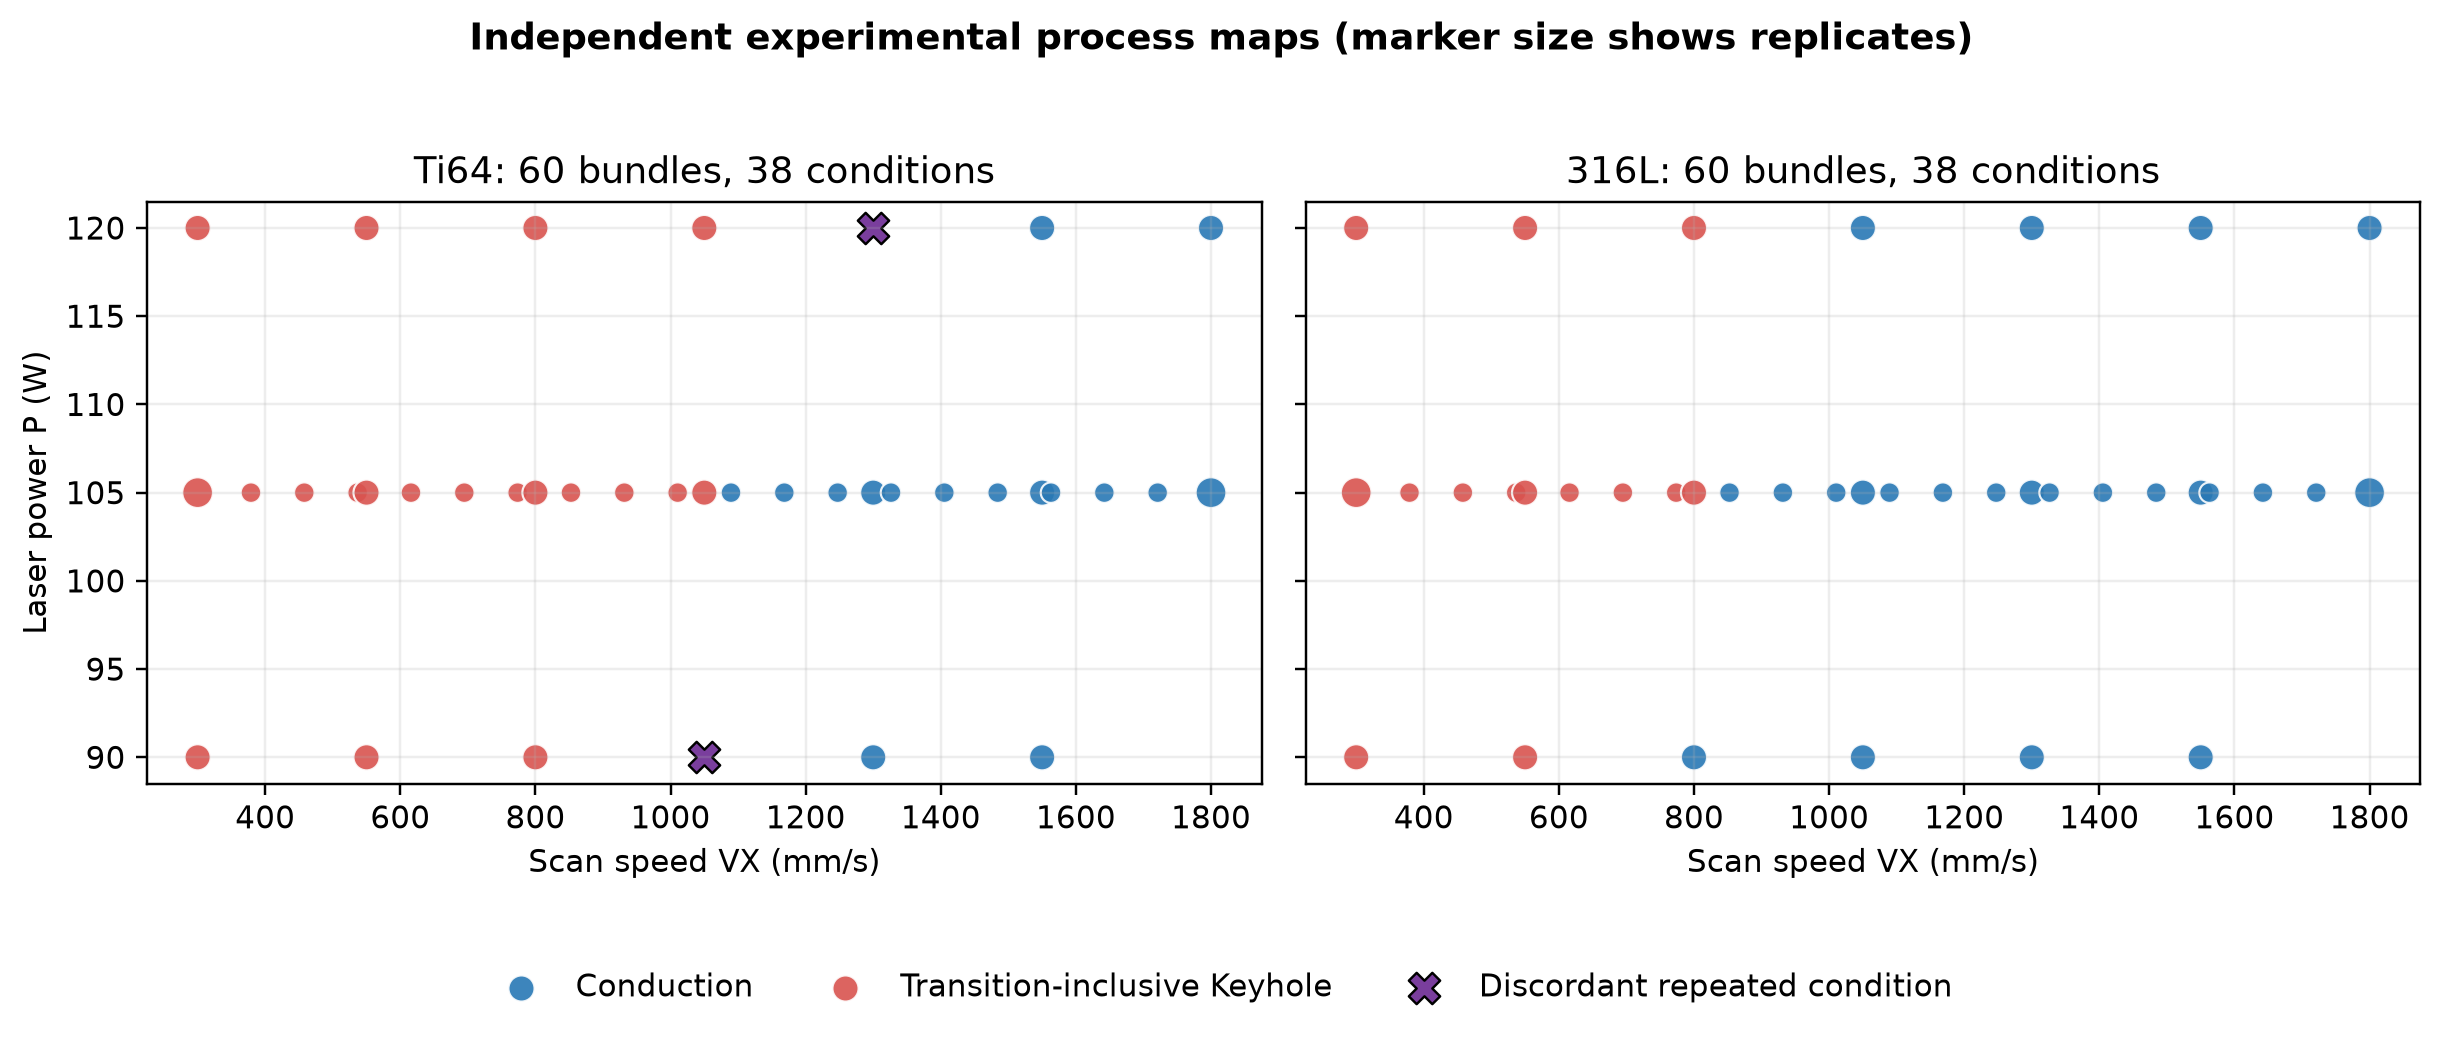

In [4]:
display(Image(filename=str(OUT/'figures'/'01_experimental_process_maps.png')))

## 4. Frozen grouped evaluation

Twenty deterministic repeats of five grouped folds produce one complete 60-bundle OOF vector per model and repeat. Metrics are computed after pooling the five folds, never as averages of tiny fold-level AUCs.

In [5]:
folds=pd.read_csv(OUT/'grouped_fold_manifest.csv')
fold_check=folds.groupby(['material','repeat','fold']).agg(rows=('bundle_id','size'), keyholes=('has_keyhole','sum'), conditions=('condition_id','nunique')).reset_index()
display(fold_check.head(10))
print('condition-fold max multiplicity:', folds.groupby(['material','repeat','condition_id']).fold.nunique().max())

,material,repeat,fold,rows,keyholes,conditions
0,316L,0,0,12,5,7
1,316L,0,1,12,4,7
2,316L,0,2,12,5,8
3,316L,0,3,12,4,8
4,316L,0,4,12,5,8
5,316L,1,0,12,4,7
6,316L,1,1,12,5,7
7,316L,1,2,12,5,8
8,316L,1,3,12,4,8
9,316L,1,4,12,5,8


condition-fold max multiplicity: 1


## 5. Ti64 primary model comparison

H is the fixed one-coordinate logistic model. G learns two slopes. The GPC is secondary and cannot redefine the primary H-versus-G test.

metric,balanced_accuracy,brier_score,keyhole_recall,pr_auc,roc_auc
model,,,,,
G,0.9503,0.0640,0.9294,0.9937,0.9921
GPC,0.9343,0.0612,0.9206,0.9918,0.9896
H,0.9226,0.0741,0.9029,0.9842,0.9765


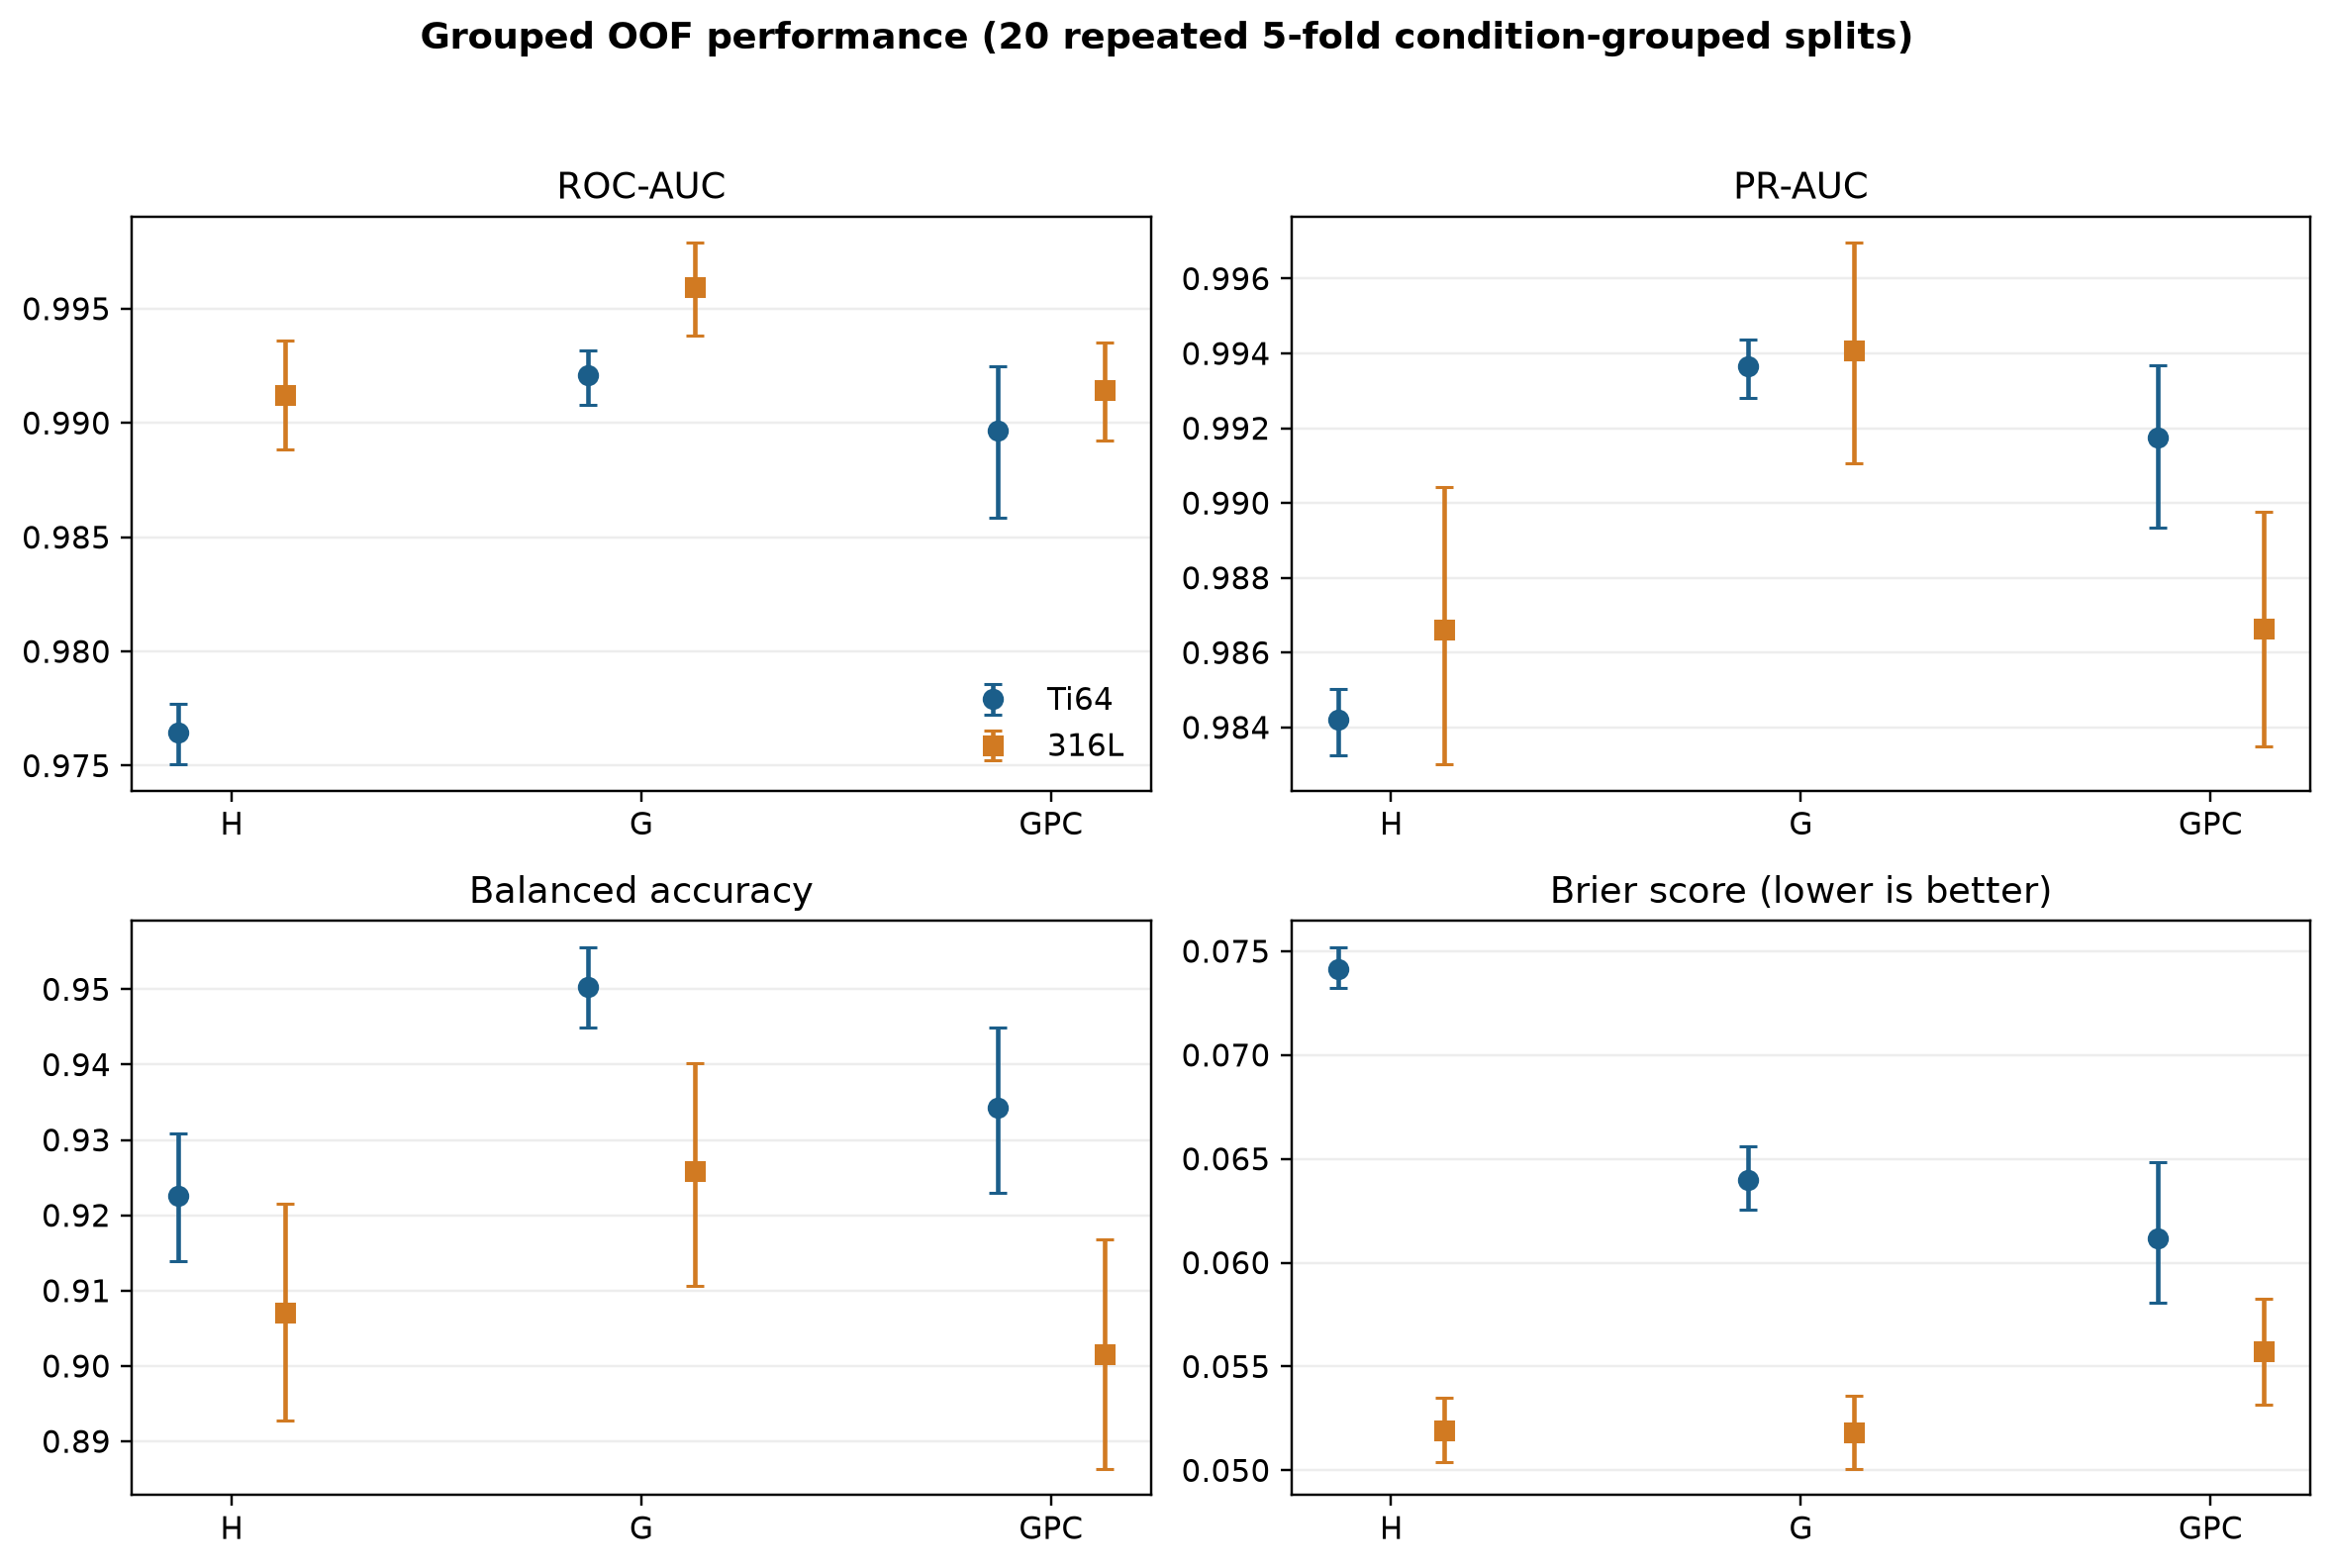

In [6]:
ti=pd.read_csv(OUT/'ti64_model_summary.csv')
display(ti[ti.metric.isin(['roc_auc','pr_auc','balanced_accuracy','keyhole_recall','brier_score'])].pivot(index='model',columns='metric',values='mean').round(4))
display(Image(filename=str(OUT/'figures'/'02_grouped_oof_performance.png')))

## 6. Paired Ti64 contrast

The 95% interval bootstraps paired repeat blocks. It measures sensitivity to the frozen grouped partitions, not 20 independent experimental datasets.

,material,contrast,metric,mean_difference,ci_lower,ci_upper,repeat_blocks,bootstrap_draws,interval_scope
0,Ti64,H_minus_G,roc_auc,-0.01561,-0.01669,-0.01454,20,10000,sensitivity to frozen grouped CV partitions; n...
1,Ti64,H_minus_G,pr_auc,-0.00945,-0.01011,-0.00876,20,10000,sensitivity to frozen grouped CV partitions; n...
2,Ti64,H_minus_G,balanced_accuracy,-0.02766,-0.03643,-0.01833,20,10000,sensitivity to frozen grouped CV partitions; n...
5,Ti64,H_minus_G,brier_score,0.01016,0.00872,0.01155,20,10000,sensitivity to frozen grouped CV partitions; n...


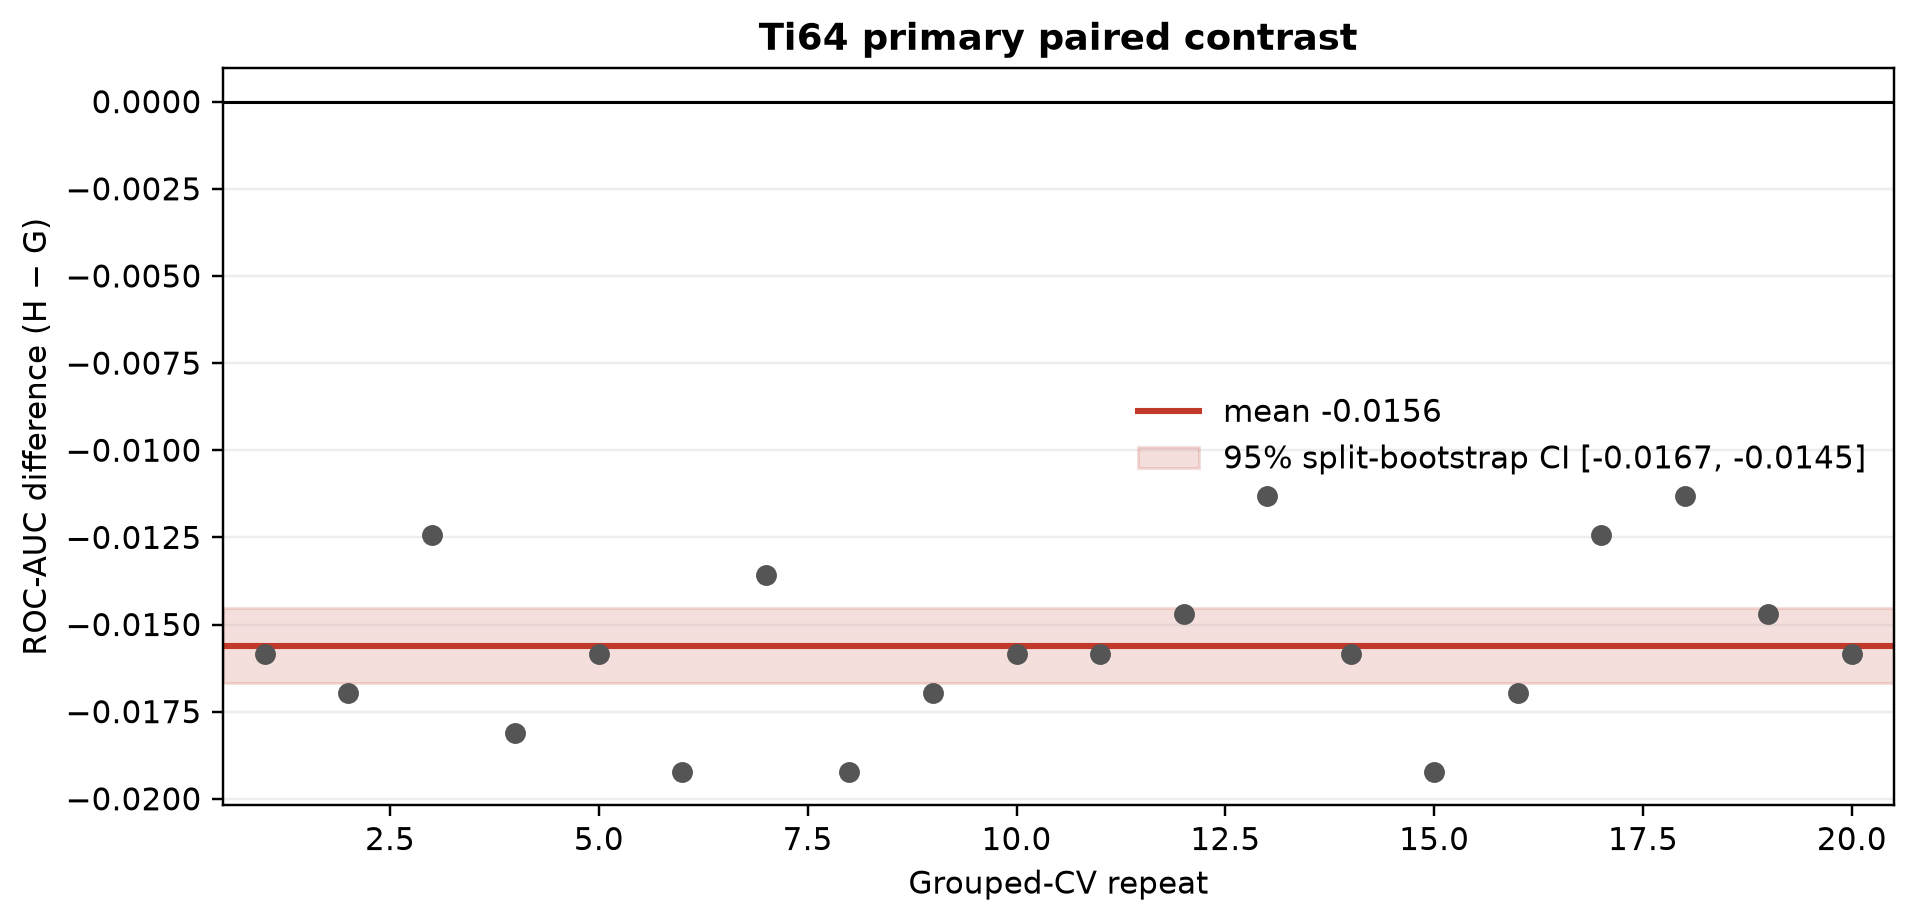

In [7]:
contrast=pd.read_csv(OUT/'ti64_paired_contrasts.csv')
display(contrast[contrast.metric.isin(['roc_auc','pr_auc','balanced_accuracy','brier_score'])].round(5))
display(Image(filename=str(OUT/'figures'/'03_ti64_H_minus_G_repeat_contrast.png')))

## 7. 316L secondary analysis

Models are refitted and evaluated within 316L. This is secondary within-material evidence, not Ti64-to-316L coefficient transfer.

In [8]:
ss=pd.read_csv(OUT/'ss316_model_summary.csv')
display(ss[ss.metric.isin(['roc_auc','pr_auc','balanced_accuracy','keyhole_recall','brier_score'])].pivot(index='model',columns='metric',values='mean').round(4))
display(pd.read_csv(OUT/'ss316_paired_contrasts.csv').query("metric == 'roc_auc'").round(5))

metric,balanced_accuracy,brier_score,keyhole_recall,pr_auc,roc_auc
model,,,,,
G,0.9258,0.0518,0.8543,0.9941,0.9959
GPC,0.9016,0.0557,0.8261,0.9866,0.9914
H,0.9071,0.0519,0.8413,0.9866,0.9912


,material,contrast,metric,mean_difference,ci_lower,ci_upper,repeat_blocks,bootstrap_draws,interval_scope
0,316L,H_minus_G,roc_auc,-0.0047,-0.00776,-0.00147,20,10000,sensitivity to frozen grouped CV partitions; n...


## 8. Discordant-condition robustness

Sensitivity A excludes non-unanimous conditions. Sensitivity B uses a strict majority and excludes ties. The two Ti64 discordances are ties, so A and B retain the same 36 conditions and must agree.

In [9]:
condition=pd.read_csv(OUT/'condition_level_sensitivity.csv')
display(condition.query("metric == 'roc_auc'").round(5))

,material,sensitivity,model_or_contrast,metric,mean,ci_lower,ci_upper,condition_rows,excluded_conditions
0,Ti64,A_exclude_discordant,H,roc_auc,0.99578,0.99406,0.99719,36,2
4,Ti64,A_exclude_discordant,G,roc_auc,0.99703,0.99547,0.99844,36,2
8,Ti64,A_exclude_discordant,H_minus_G,roc_auc,-0.00125,-0.00266,0.00016,36,2
12,Ti64,B_strict_majority,H,roc_auc,0.99578,0.99406,0.99719,36,2
16,Ti64,B_strict_majority,G,roc_auc,0.99703,0.99547,0.99844,36,2
20,Ti64,B_strict_majority,H_minus_G,roc_auc,-0.00125,-0.00266,0.00016,36,2
24,316L,A_exclude_discordant,H,roc_auc,0.99524,0.99390,0.99658,38,0
28,316L,A_exclude_discordant,G,roc_auc,0.99821,0.99702,0.99926,38,0
32,316L,A_exclude_discordant,H_minus_G,roc_auc,-0.00298,-0.00506,-0.00074,38,0
36,316L,B_strict_majority,H,roc_auc,0.99524,0.99390,0.99658,38,0


## 9. Required PCA backup

PCA is fitted label-free on standardized `[log P, log VX]`; colors are applied only after fitting. Because the original feature space is already 2D, PCA rotates it but does not reduce dimension and is not used by any model.

,material,component,feature,loading,explained_variance_ratio,fit_features,labels_used_in_fit
0,Ti64,PC1,log_P,0.7071,0.5334,log_P|log_VX,False
1,Ti64,PC1,log_VX,0.7071,0.5334,log_P|log_VX,False
2,Ti64,PC2,log_P,-0.7071,0.4666,log_P|log_VX,False
3,Ti64,PC2,log_VX,0.7071,0.4666,log_P|log_VX,False
4,316L,PC1,log_P,0.7071,0.5334,log_P|log_VX,False
5,316L,PC1,log_VX,0.7071,0.5334,log_P|log_VX,False
6,316L,PC2,log_P,-0.7071,0.4666,log_P|log_VX,False
7,316L,PC2,log_VX,0.7071,0.4666,log_P|log_VX,False


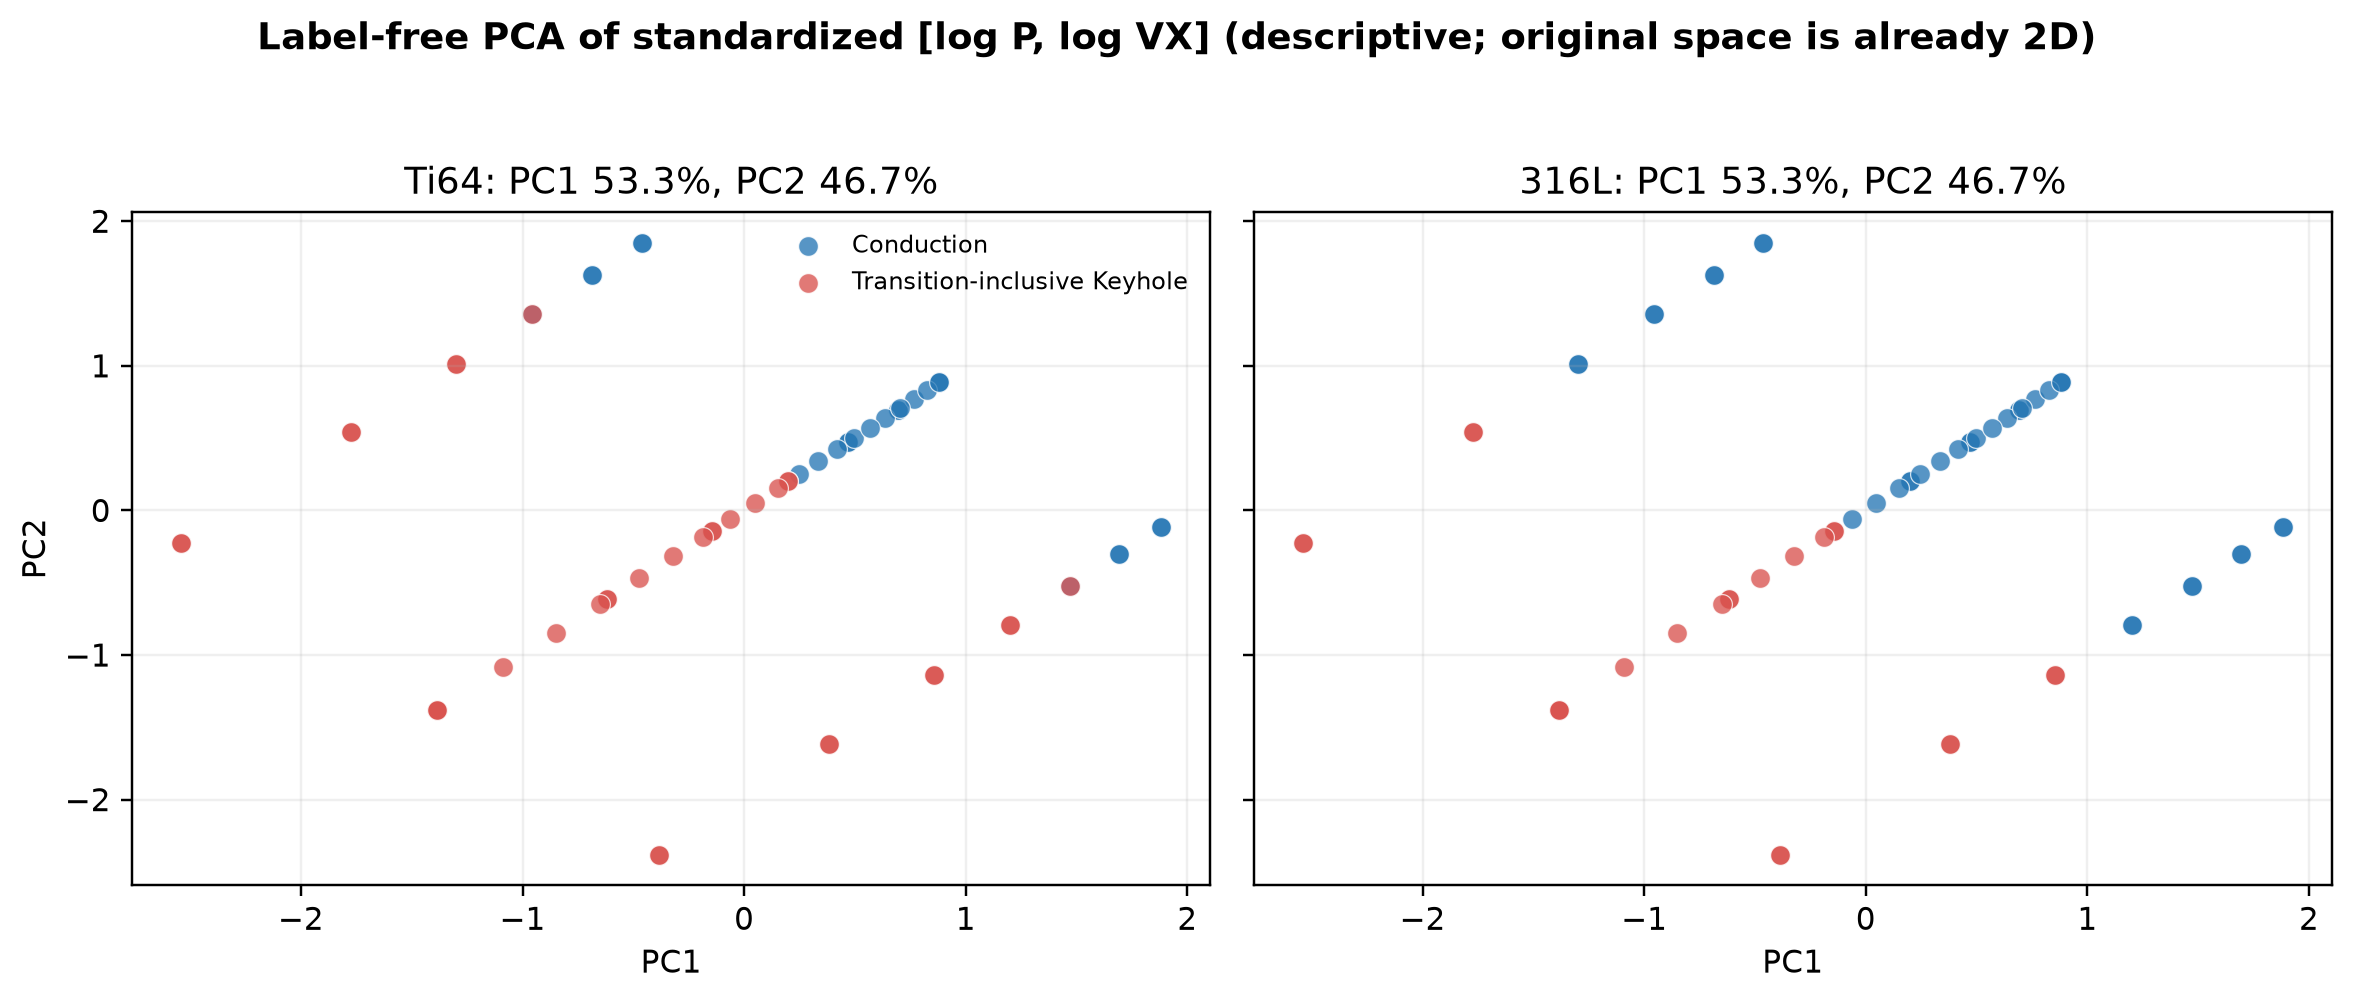

In [10]:
display(pd.read_csv(OUT/'pca_loadings.csv').round(4))
display(Image(filename=str(OUT/'figures'/'04_label_free_process_pca.png')))

## 10. Supported conclusion and boundaries

The fixed physics direction is a strong experimental discriminator. The generic two-slope logistic is modestly but consistently better in the primary bundle-level Ti64 protocol; after excluding the two discordant repeated conditions, the H–G gap is small and unresolved. This does not validate the LS exponent, prove SPH physics, transfer a threshold across alloys, or demonstrate active-learning benefit.

In [11]:
display(Markdown((OUT/'SUPERVISOR_PHASE1_10_ONE_PAGE.md').read_text()))

# Supervisor one-page â€” Week 9 Phase 1.10

## What was tested

On Masinelli et al.'s independent experimental LPBF data, we compared a fixed physics direction `log h = const + log P - 0.5 log VX` with a generic two-slope `[log P, log VX]` logistic model. The target is transition-inclusive post-mortem morphology, so this is independent but non-identical validation.

## Data and fairness

- Ti64 (primary): 60 bundles, 38 unique conditions, 26 Conduction / 34 Keyhole; two repeated conditions have conflicting binary labels.
- 316L (secondary): 60 bundles, 38 conditions, 37 / 23; no binary-discordant condition.
- 20 Ã— 5 grouped OOF; exact `(P,VX)` repeats never cross folds; complete 60-bundle OOF vector scored per repeat.
- `LS=25 Âµm` radius from the reported 50 Âµm `1/eÂ²` diameter. Because LS is constant, only the `P*VX^-1/2` directionâ€”not the LS exponentâ€”is tested.

## Primary Ti64 result

- H: ROC-AUC 0.9765; PR-AUC 0.9842; balanced accuracy 0.9226; Keyhole recall 0.9029; Brier 0.0741.
- G: ROC-AUC 0.9921; PR-AUC 0.9937; balanced accuracy 0.9503; Keyhole recall 0.9294; Brier 0.0640.
- Hâˆ’G ROC-AUC: -0.0156, 95% split-bootstrap CI [-0.0167, -0.0145].
- Secondary GPC ROC-AUC: 0.9896.

Verdict: **GENERIC_DIRECTION_SUPERIOR**. `h` is strongly discriminative, but fixing the âˆ’1/2 velocity exponent loses a small, stable amount relative to the generic two-slope model.

## Robustness and 316L

Excluding the two discordant Ti64 conditions raises H/G ROC-AUC to 0.9958/0.9970; Hâˆ’G becomes -0.0012 [-0.0027, +0.0002], unresolved. In 316L, H/G ROC-AUC are 0.9912/0.9959; Hâˆ’G -0.0047 [-0.0078, -0.0015].

## Safe conclusion

The physics-aligned direction transfers as a strong experimental discriminator, not as the optimal or universal law. The generic direction is better on the primary bundle-level protocol; the gap is largely attenuated when discordant repeated conditions are excluded. External AL replay is feasible but should be exploratory, not the next confirmatory claim.
